### Pairs trading with 5 assets

Overall, the exercise suggests that even a very simple cross-sectional stat-arb construction can improve risk adjusted returns with respect to a simple 50/50 buy & hold benchmark, which is notable given that short-horizon relative-value signals are widely researched and heavily contested across the industry. The more important takeaway is that a basic, crowded formulation still appears to retain some value, implying that careful improvements such as better neutralization, transaction cost modeling, execution lags, and alternative “less-contested” feature spaces—could bring more meaningful incremental performance.

In [20]:
import yfinance as yf
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 

### Download tickers

In [21]:
assets = ['JPM', 'BAC', 'C', 'GS', 'MS']

data = yf.download(tickers=assets, interval='1d', start='2010-01-01')['Close']

data = data.dropna()

print(data.head())
print(data.tail())

[*********************100%***********************]  5 of 5 completed

Ticker            BAC          C          GS        JPM         MS
Date                                                              
2010-01-04  12.169186  25.228098  130.641525  28.423927  21.862959
2010-01-05  12.564745  26.192698  132.951233  28.974504  22.662220
2010-01-06  12.712108  27.008909  131.532181  29.133701  22.952223
2010-01-07  13.130933  27.083092  134.106049  29.710802  23.284657
2010-01-08  13.014589  26.637897  131.569992  29.637836  22.810749
Ticker            BAC           C          GS         JPM          MS
Date                                                                 
2026-01-16  52.970001  118.040001  962.000000  312.470001  189.089996
2026-01-20  52.099998  112.800003  943.369995  302.739990  182.100006
2026-01-21  52.070000  113.860001  953.010010  302.040009  183.320007
2026-01-22  52.450001  115.660004  954.650024  303.630005  183.050003
2026-01-23  51.720001  113.589996  918.880005  297.720001  179.000000


### Obtaining returns

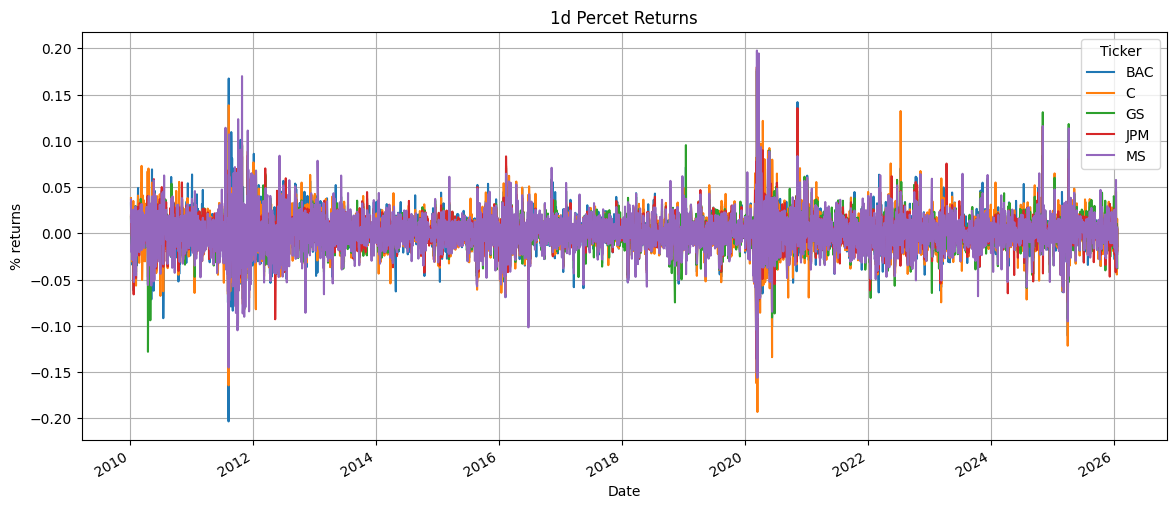

In [22]:
returns = data.pct_change()

returns.plot(grid=True, figsize=(14,6))
plt.title("1d Percet Returns")
plt.ylabel('% returns')
plt.show()

### Extracting signals 

this is done based on how much their individual returns deviate from the average on a 5 day rolling period and that translates into the weights

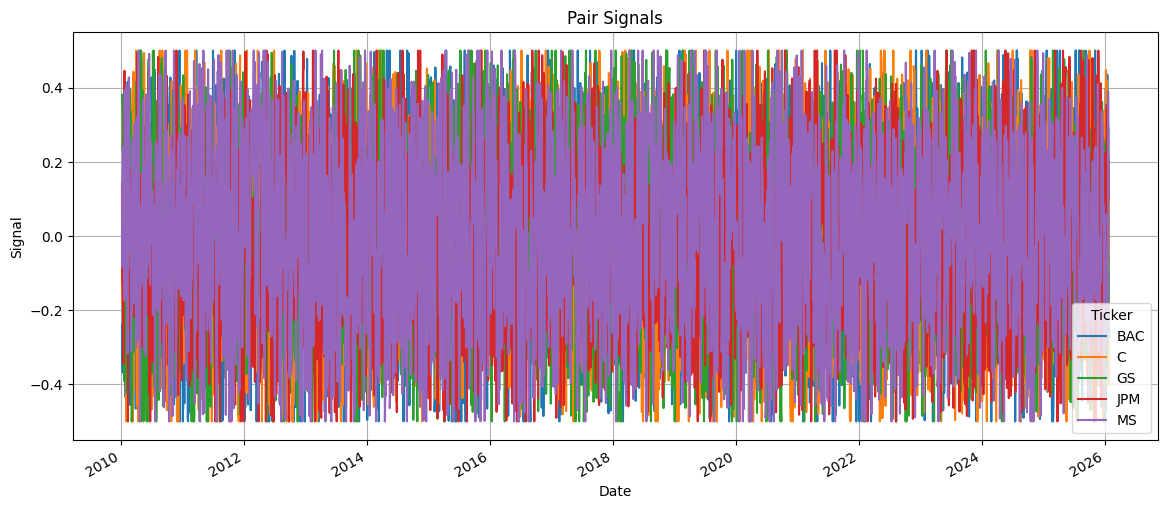

In [23]:
pair_signal = -(returns.rolling(3).sum().subtract(
    returns.rolling(3).sum().mean(axis=1), 
    axis=0
    )
)

pair_signal = (pair_signal.divide(
    pair_signal.abs().sum(axis=1),
    axis = 0
    )
)

pair_signal.plot(grid=True, figsize=(14,6))
plt.title('Pair Signals')
plt.ylabel('Signal')
plt.show()

### Returns without reinvestments

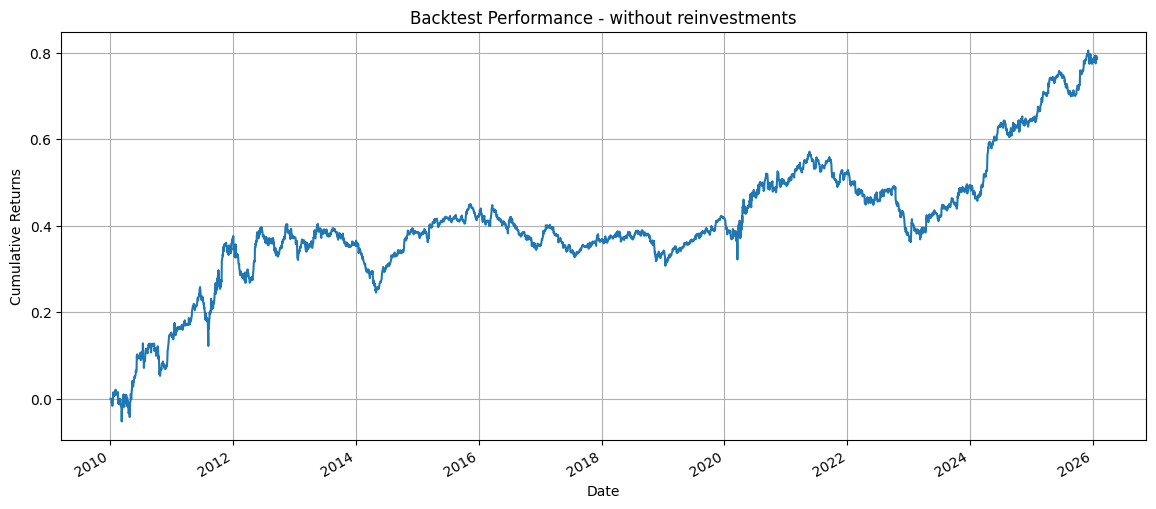

In [24]:
performance = pair_signal.shift(1).multiply(returns).sum(axis=1).cumsum()

performance.plot(grid=True, figsize=(14, 6))
plt.title('Backtest Performance - without reinvestments')
plt.ylabel('Cumulative Returns')
plt.show()

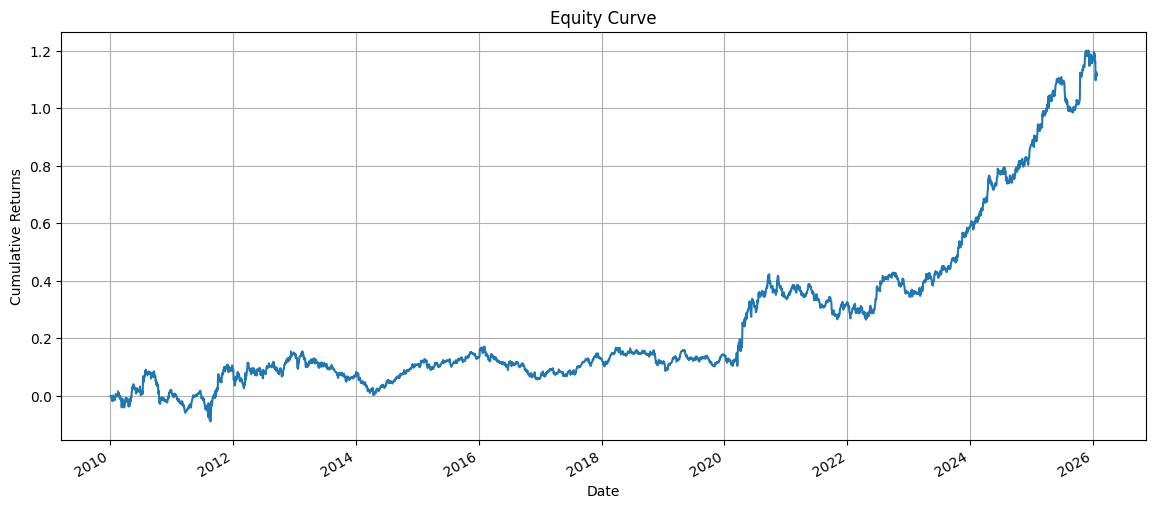

In [25]:
daily_pnl = pair_signal.shift(2).multiply(returns).sum(1)
equity_curve = (1 + daily_pnl).cumprod() - 1

equity_curve.plot(grid=True, figsize=(14, 6))
plt.title('Equity Curve')
plt.ylabel('Cumulative Returns')
plt.show()

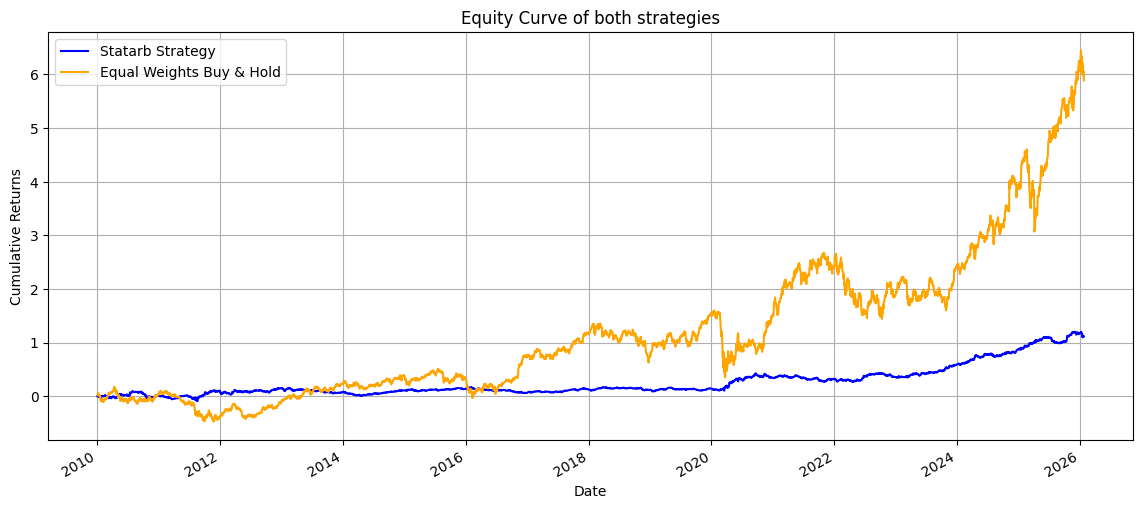

In [26]:
px = (1 + returns).cumprod() 
equal_weights_bh = (0.20 * px.iloc[:,0] + 0.20 * px.iloc[:,1] + 0.20 * px.iloc[:,2] + 0.20 * px.iloc[:,3] + 0.20 * px.iloc[:,4]) - 1

df = pd.concat([equity_curve.rename('Statarb Strategy'), equal_weights_bh.rename('Equal Weights Buy & Hold')], axis=1)

df.plot(grid=True, figsize=(14, 6), color=["blue", "orange"],)
plt.title('Equity Curve of both strategies')
plt.ylabel('Cumulative Returns')
plt.show()

### Performance Stats - Statarb Strategy

In [27]:
total_return = equity_curve.iloc[-1]
annual_vol = daily_pnl.std() * np.sqrt(252)
sharpe = (daily_pnl.mean() / daily_pnl.std()) * np.sqrt(252)

print('Statarb')
print('Total return: ', total_return)
print('Volatility: ', annual_vol)
print('Sharpe Ratio: ', sharpe)

Statarb
Total return:  1.1140309486081041
Volatility:  0.07915180243065845
Sharpe Ratio:  0.6296307725209798


### Performance Stats - 50/50 Buy & Hold

In [28]:
total_return_bh = equal_weights_bh.iloc[-1]
bh_daily_ret = equal_weights_bh.pct_change().dropna()
annual_vol_bh = bh_daily_ret.std() * np.sqrt(252)
sharpe_bh = (bh_daily_ret.mean() / bh_daily_ret.std()) * np.sqrt(252)

print('Buy & Hold Benchmark')
print('Total return: ', total_return_bh)
print('Volatility: ', annual_vol_bh)
print('Sharpe Ratio: ', sharpe_bh)

Buy & Hold Benchmark
Total return:  5.889566879844823
Volatility:  83.3255828890845
Sharpe Ratio:  -0.2752403073282771
